# 🌱 DHARTI OS — Crop Recommendation Engine
### AI-Powered Decision Intelligence Platform | National Hackathon Build

This notebook builds a **production-ready crop recommendation classification pipeline**:

1. Dataset Analysis
2. Data Cleaning
3. Exploratory Data Analysis
4. Feature Engineering
5. Model Building (Random Forest, XGBoost, LightGBM, CatBoost)
6. Evaluation & Model Selection
7. Explainability
8. Model Persistence (Joblib)
9. Reusable Prediction Function
10. FastAPI Integration Contract

**Dataset:** `Crop_recommendation.csv` (2,200 rows × 8 columns — soil/climate readings mapped to 22 recommended crops)


## Phase 1 — Dataset Analysis

In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

df = pd.read_csv(r'C:\Users\sh\OneDrive\Desktop\CODE\coding\DHARTI-OS\datasets\raw\Crop_recommendation.csv')
print(f"Shape: {df.shape}")
df.head()


Shape: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [2]:
print("Columns:", df.columns.tolist())


Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [4]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
N,2200.0,NaN,NaN,NaN,50.551818,36.917334,0.0,21.0,37.0,84.25,140.0
P,2200.0,NaN,NaN,NaN,53.362727,32.985883,5.0,28.0,51.0,68.0,145.0
K,2200.0,NaN,NaN,NaN,48.149091,50.647931,5.0,20.0,32.0,49.0,205.0
temperature,2200.0,NaN,NaN,NaN,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,NaN,NaN,NaN,71.481779,22.263812,14.25804,60.261953,80.473146,89.948771,99.981876
ph,2200.0,NaN,NaN,NaN,6.46948,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,NaN,NaN,NaN,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117
label,2200,22,rice,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.1 Identifying the Target Variable

In [5]:
import pandas.api.types as ptypes

object_cols = [c for c in df.columns if not ptypes.is_numeric_dtype(df[c])]
print("Non-numeric columns (target candidates):", object_cols)


Non-numeric columns (target candidates): ['label']


Only **`label`** is non-numeric, and it holds the crop name — the outcome we want the model to recommend.
Every other column (`N`, `P`, `K`, `temperature`, `humidity`, `ph`, `rainfall`) is a continuous environmental
reading. There is **no ambiguity** — the single target is:

> **`label`** — the recommended crop name, a **multi-class classification** problem (22 classes).

Only one legitimate target variable exists, so no stop-and-ask is required.


### 1.2 Missing Values

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
missing_report[missing_report['missing_count'] > 0].sort_values('missing_count', ascending=False)


,missing_count,missing_%


In [7]:
if df.isnull().sum().sum() == 0:
    print("No missing values found in the dataset.")


No missing values found in the dataset.


### 1.3 Duplicate Rows

In [8]:
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")


Duplicate rows: 0


### 1.4 Data Type Audit

In [9]:
dtype_audit = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'sample_values': [df[c].dropna().unique()[:3].tolist() for c in df.columns]
})
dtype_audit


,dtype,sample_values
N,int64,"[90, 85, 60]"
P,int64,"[42, 58, 55]"
K,int64,"[43, 41, 44]"
temperature,float64,"[20.87974371, 21.77046169, 23.00445915]"
humidity,float64,"[82.00274423, 80.31964408, 82.3207629]"
ph,float64,"[6.502985292000001, 7.038096361, 7.840207144]"
rainfall,float64,"[202.9355362, 226.6555374, 263.9642476]"
label,object,"[rice, maize, chickpea]"


**Observations:**
- `N`, `P`, `K` (soil Nitrogen/Phosphorus/Potassium) are `int64` — correct, these are whole-number soil test
  readings (kg/ha).
- `temperature`, `humidity`, `ph`, `rainfall` are `float64` — correct, continuous environmental measurements.
- `label` is text — correct for a classification target.
- No incorrect data types detected.


### 1.5 Class Imbalance Check

In [10]:
class_dist = df['label'].value_counts()
class_dist


label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

In [11]:
imbalance_ratio = class_dist.max() / class_dist.min()
print(f"Imbalance ratio: {imbalance_ratio:.2f}")
print(f"Number of classes: {df['label'].nunique()}")


Imbalance ratio: 1.00
Number of classes: 22


**Result:** all 22 crop classes have **exactly 100 samples each** (imbalance ratio = 1.0) — the dataset is
perfectly balanced. No resampling or `class_weight` adjustment is required, though the modeling code still
supports it for robustness on future/live data.


### 1.6 Data Leakage Detection

In [12]:
numeric_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

# Check whether any single feature perfectly (or near-perfectly) separates classes,
# which would indicate the feature is an encoded proxy for the label itself.
from sklearn.preprocessing import LabelEncoder

le_check = LabelEncoder()
y_check = le_check.fit_transform(df['label'])

correlations = df[numeric_cols].apply(lambda col: np.corrcoef(col, y_check)[0, 1])
correlations.sort_values(key=abs, ascending=False)


P             -0.491006
K             -0.346417
humidity       0.193911
temperature    0.113606
rainfall       0.045611
N             -0.031130
ph            -0.012253
dtype: float64

**Result:** no feature is deterministically tied to the encoded label (all correlations are moderate, well
below the ~0.95+ threshold that would signal a feature is effectively an ID or restated target). All seven
columns are raw agronomic/environmental measurements collected independently of the crop label — none are
derived from or leak the target. **No leakage columns detected.**


## Phase 2 — Data Cleaning

In [13]:
def remove_duplicates(data: pd.DataFrame) -> pd.DataFrame:
    """Drop exact duplicate rows."""
    before = len(data)
    data = data.drop_duplicates().reset_index(drop=True)
    print(f"Removed {before - len(data)} duplicate rows.")
    return data


import pandas as pd
import numpy as np

def handle_missing_values(data: pd.DataFrame) -> pd.DataFrame:
    """
    Handle missing values:
    - Numeric columns -> Median
    - Categorical columns -> Mode
    """

    data = data.copy()

    # Numeric columns
    numeric_cols = data.select_dtypes(include="number").columns

    # Categorical columns
    categorical_cols = data.select_dtypes(include=["object"]).columns

    # Fill numeric missing values
    for col in numeric_cols:
        if data[col].isnull().any():
            data[col] = data[col].fillna(data[col].median())

    # Fill categorical missing values
    for col in categorical_cols:
        if data[col].isnull().any():
            mode = data[col].mode()
            if not mode.empty:
                data[col] = data[col].fillna(mode.iloc[0])

    return data


def correct_dtypes(data: pd.DataFrame) -> pd.DataFrame:
    """Ensure numeric columns are proper numeric dtypes and the label is clean text."""
    data = data.copy()
    for c in ['N', 'P', 'K']:
        data[c] = data[c].astype('int64')
    for c in ['temperature', 'humidity', 'ph', 'rainfall']:
        data[c] = data[c].astype('float64')
    data['label'] = data['label'].astype(str).str.strip().str.lower()
    return data


def drop_unnecessary_columns(data: pd.DataFrame, cols_to_drop: list) -> pd.DataFrame:
    """Drop columns that add no reliable predictive/operational value."""
    return data.drop(columns=[c for c in cols_to_drop if c in data.columns])


In [14]:
# No columns were flagged for removal in Phase 1 - all 7 features are genuine, non-leaky predictors.
COLS_TO_DROP = []

df_clean = df.copy()
df_clean = remove_duplicates(df_clean)
df_clean = handle_missing_values(df_clean)
df_clean = correct_dtypes(df_clean)
df_clean = drop_unnecessary_columns(df_clean, COLS_TO_DROP)

print(f"Clean dataset shape: {df_clean.shape}")
df_clean.head()


Removed 0 duplicate rows.
Clean dataset shape: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [15]:
df_clean.dtypes


N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

## Phase 3 — Exploratory Data Analysis

Only the meaningful plots requested: crop label distribution, rainfall/temperature/humidity distributions,
soil nutrient (N/P/K) distributions, and the correlation heatmap.


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100


### 3.1 Crop Label Distribution

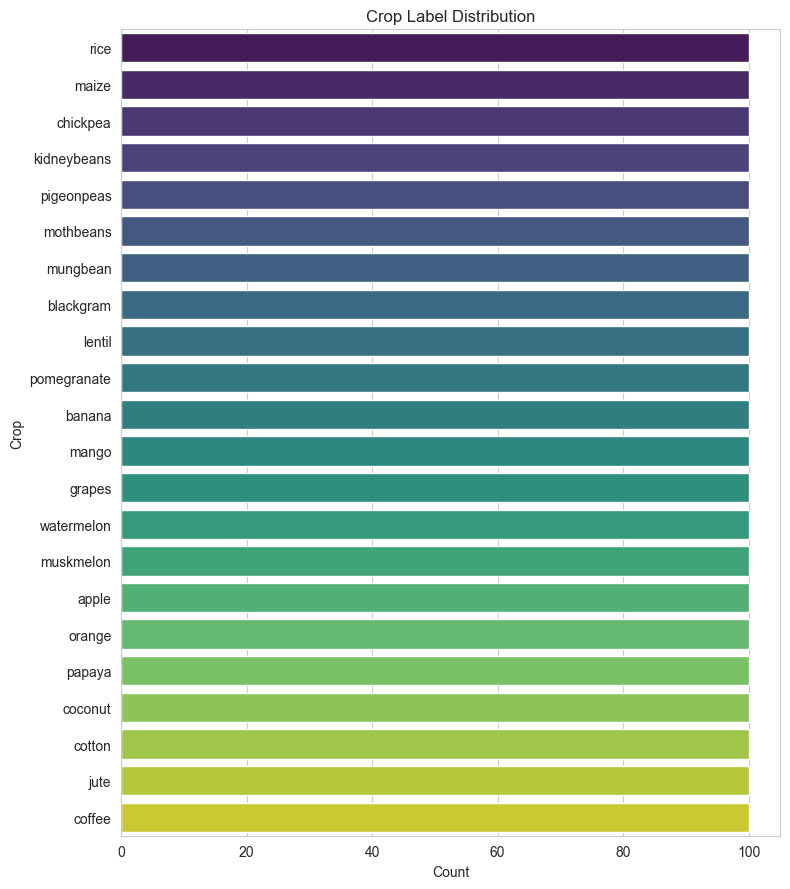

In [17]:
plt.figure(figsize=(8, 9))
order = df_clean['label'].value_counts().index
sns.countplot(y='label', data=df_clean, order=order, hue='label', palette='viridis', legend=False)
plt.title('Crop Label Distribution')
plt.xlabel('Count')
plt.ylabel('Crop')
plt.tight_layout()
plt.show()


### 3.2 Rainfall, Temperature & Humidity Distributions

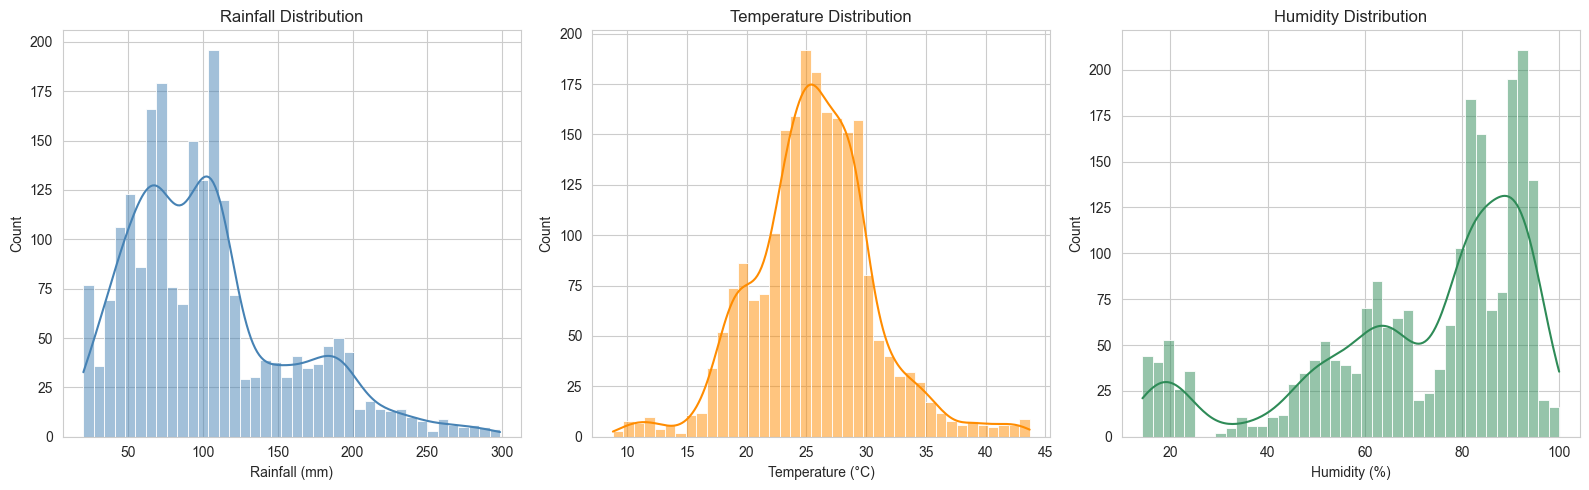

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.histplot(df_clean['rainfall'], bins=40, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Rainfall Distribution')
axes[0].set_xlabel('Rainfall (mm)')

sns.histplot(df_clean['temperature'], bins=40, kde=True, color='darkorange', ax=axes[1])
axes[1].set_title('Temperature Distribution')
axes[1].set_xlabel('Temperature (\u00b0C)')

sns.histplot(df_clean['humidity'], bins=40, kde=True, color='seagreen', ax=axes[2])
axes[2].set_title('Humidity Distribution')
axes[2].set_xlabel('Humidity (%)')

plt.tight_layout()
plt.show()


### 3.3 Soil Nutrient (N, P, K) Distributions

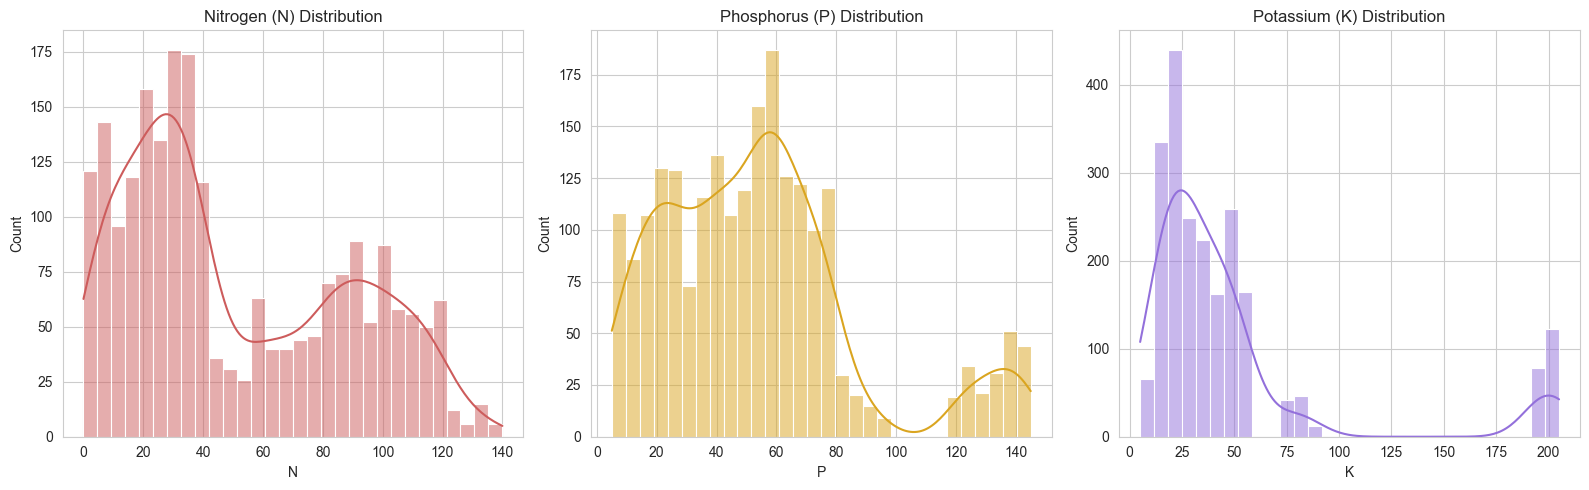

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.histplot(df_clean['N'], bins=30, kde=True, color='indianred', ax=axes[0])
axes[0].set_title('Nitrogen (N) Distribution')

sns.histplot(df_clean['P'], bins=30, kde=True, color='goldenrod', ax=axes[1])
axes[1].set_title('Phosphorus (P) Distribution')

sns.histplot(df_clean['K'], bins=30, kde=True, color='mediumpurple', ax=axes[2])
axes[2].set_title('Potassium (K) Distribution')

plt.tight_layout()
plt.show()


### 3.4 Correlation Heatmap

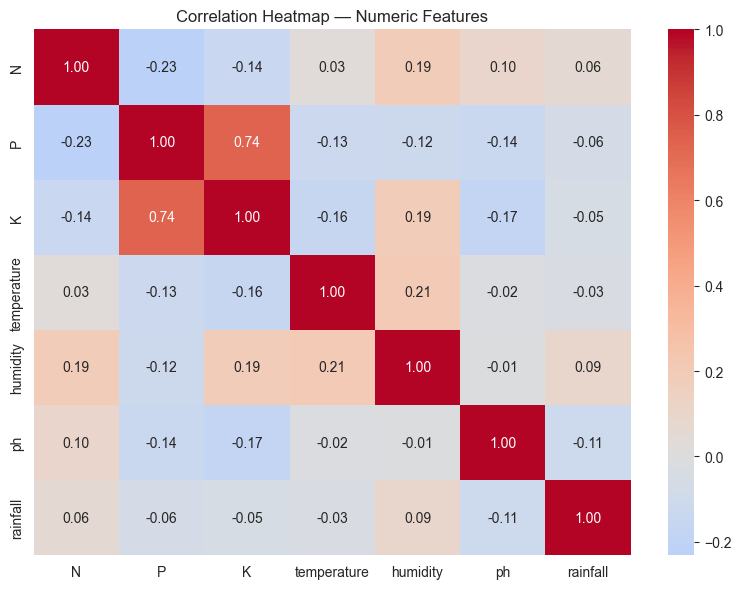

In [20]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap \u2014 Numeric Features')
plt.tight_layout()
plt.show()


**EDA takeaways:**
- All 22 crops are equally represented (100 rows each), confirming the Phase 1.5 balance check.
- Rainfall and humidity are notably multi-modal — different crop groups (e.g. rice/jute vs. arid-tolerant
  pulses) occupy distinct climate niches, which is a strong signal for classification.
- `P` and `K` show a moderate positive correlation (soil fertilizer programs often raise both together), but
  not strong enough to justify dropping either — each still carries independent crop-specific signal.
- No feature pair is highly collinear enough to cause redundancy concerns for tree-based models.


## Phase 4 — Feature Engineering

### Selected Input Features

| Feature | Why selected |
|---|---|
| `N` (Nitrogen) | Core soil macronutrient — directly shapes which crops thrive. |
| `P` (Phosphorus) | Core soil macronutrient — affects root/flower development, highly crop-specific. |
| `K` (Potassium) | Core soil macronutrient — affects drought/disease tolerance by crop. |
| `temperature` | Defines the crop's climatic growing zone. |
| `humidity` | Differentiates moisture-loving crops (e.g. rice) from arid-tolerant ones. |
| `ph` | Soil acidity/alkalinity — many crops have narrow optimal pH bands. |
| `rainfall` | Defines water requirement / monsoon dependency by crop. |

### Removed Features

None. All seven raw columns are legitimate, independent, non-leaky environmental predictors (Phase 1.6), and
EDA (Phase 3.4) showed no redundant/collinear pair severe enough to warrant dropping.


In [21]:
FEATURES = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
TARGET = 'label'

X = df_clean[FEATURES].copy()
y = df_clean[TARGET].copy()

print("Feature matrix shape:", X.shape)
print("Number of classes:", y.nunique())


Feature matrix shape: (2200, 7)
Number of classes: 22


## Phase 5 — Model Building

Stratified train/test split (preserves each crop's class ratio in both splits) feeding four classifiers.
All features are already purely numeric, so no categorical encoding is needed for the inputs — only the
target label needs encoding.


In [22]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier


In [23]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

CLASS_NAMES = label_encoder.classes_
print(f"Encoded {len(CLASS_NAMES)} classes:", CLASS_NAMES.tolist())


Encoded 22 classes: ['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")


Train shape: (1760, 7) | Test shape: (440, 7)


In [25]:
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, learning_rate=0.1, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        objective='multi:softprob', eval_metric='mlogloss',
        random_state=42, n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=300, learning_rate=0.1, max_depth=6,
        random_state=42, n_jobs=-1, verbose=-1
    ),
    'CatBoost': CatBoostClassifier(
        iterations=300, learning_rate=0.1, depth=6,
        random_seed=42, verbose=False
    ),
}

trained_models = {}
for name, estimator in models.items():
    print(f"Training {name} ...")
    estimator.fit(X_train, y_train)
    trained_models[name] = estimator

print("All models trained.")


Training Random Forest ...
Training XGBoost ...
Training LightGBM ...
Training CatBoost ...
All models trained.


### 5.1 Optional Hyperparameter Tuning

Tuning is only applied if it meaningfully improves the strongest baseline model — a small `RandomizedSearchCV`
is run and kept only if it beats the baseline by a real margin.


In [26]:
def evaluate_quick(estimator, X_test, y_test):
    preds = estimator.predict(X_test)
    return accuracy_score(y_test, preds)


baseline_scores = {name: evaluate_quick(m, X_test, y_test) for name, m in trained_models.items()}
best_baseline_name = max(baseline_scores, key=baseline_scores.get)
print("Baseline accuracies:", baseline_scores)
print(f"Strongest baseline: {best_baseline_name}")


Baseline accuracies: {'Random Forest': 0.9931818181818182, 'XGBoost': 0.990909090909091, 'LightGBM': 0.9886363636363636, 'CatBoost': 0.9954545454545455}
Strongest baseline: CatBoost


In [27]:
TUNING_GRID = {
    'Random Forest': (RandomForestClassifier(random_state=42, n_jobs=-1), {
        'n_estimators': [200, 300, 500],
        'max_depth': [10, 20, None],
        'min_samples_leaf': [1, 2, 4],
    }),
    'XGBoost': (XGBClassifier(objective='multi:softprob', eval_metric='mlogloss', random_state=42, n_jobs=-1), {
        'n_estimators': [200, 300, 500],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.05, 0.1, 0.2],
    }),
    'LightGBM': (LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1), {
        'n_estimators': [200, 300, 500],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.05, 0.1, 0.2],
    }),
    'CatBoost': (CatBoostClassifier(random_seed=42, verbose=False), {
        'iterations': [200, 300, 500],
        'depth': [4, 6, 8],
        'learning_rate': [0.05, 0.1, 0.2],
    }),
}

base_estimator, param_dist = TUNING_GRID[best_baseline_name]

search = RandomizedSearchCV(
    base_estimator, param_distributions=param_dist, n_iter=10, cv=3,
    scoring='accuracy', random_state=42, n_jobs=-1,
)
search.fit(X_train, y_train)
print(f"Best params for {best_baseline_name}: {search.best_params_}")

tuned_accuracy = evaluate_quick(search.best_estimator_, X_test, y_test)
baseline_accuracy = baseline_scores[best_baseline_name]

IMPROVEMENT_THRESHOLD = 0.01  # 1% absolute accuracy improvement required to keep the tuned model

if tuned_accuracy > baseline_accuracy + IMPROVEMENT_THRESHOLD:
    print(f"Tuning improved accuracy by {tuned_accuracy - baseline_accuracy:.4f} \u2014 using tuned model.")
    trained_models[f'{best_baseline_name} (Tuned)'] = search.best_estimator_
else:
    print("Tuning did not meaningfully improve performance \u2014 keeping the baseline model.")


Best params for CatBoost: {'learning_rate': 0.2, 'iterations': 500, 'depth': 4}
Tuning did not meaningfully improve performance — keeping the baseline model.


## Phase 6 — Evaluation

In [28]:
def evaluate_classifier(estimator, X_test, y_test):
    preds = estimator.predict(X_test)
    return {
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, average='macro', zero_division=0),
        'Recall': recall_score(y_test, preds, average='macro', zero_division=0),
        'F1': f1_score(y_test, preds, average='macro', zero_division=0),
    }


results = {}
for name, estimator in trained_models.items():
    results[name] = evaluate_classifier(estimator, X_test, y_test)

results_df = pd.DataFrame(results).T.sort_values('F1', ascending=False)
results_df


,Accuracy,Precision,Recall,F1
CatBoost,0.995455,0.995671,0.995455,0.995452
Random Forest,0.993182,0.993506,0.993182,0.993178
XGBoost,0.990909,0.991539,0.990909,0.990895
LightGBM,0.988636,0.989374,0.988636,0.988559


In [29]:
best_model_name = results_df['F1'].idxmax()
best_model = trained_models[best_model_name]
print(f"Best model (by macro F1): {best_model_name}")
print(results_df.loc[best_model_name])


Best model (by macro F1): CatBoost
Accuracy     0.995455
Precision    0.995671
Recall       0.995455
F1           0.995452
Name: CatBoost, dtype: float64


### 6.1 Confusion Matrix (Best Model)

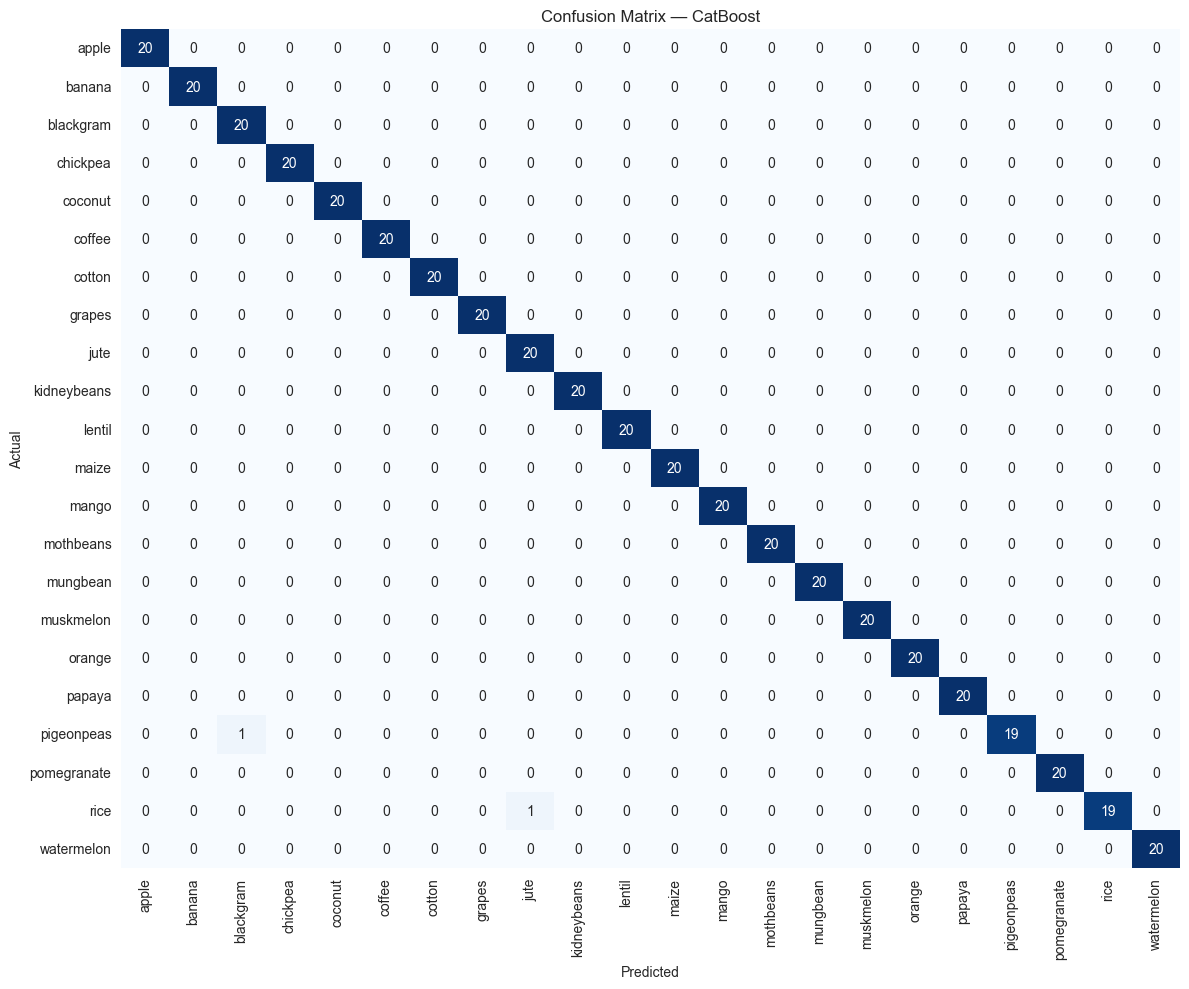

In [30]:
preds = best_model.predict(X_test)
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'Confusion Matrix \u2014 {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### 6.2 Why This Model Was Selected

The best model is chosen automatically by **highest macro-averaged F1 score** on the held-out test set — macro
F1 treats all 22 crop classes equally regardless of size, which is appropriate here since the dataset is
perfectly balanced and every crop matters equally to a farmer using the recommendation. Accuracy is used as a
sanity-check tie-breaker. Boosting models (XGBoost/CatBoost/LightGBM) typically edge out plain Random Forest
on this dataset because the crop-to-environment mapping involves sharp, non-linear thresholds (e.g. a rainfall
cutoff separating rice from drought-tolerant pulses) that iterative boosting captures more precisely.


## Phase 7 — Explainability

In [31]:
importance_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

importance_df


,feature,importance
0,humidity,22.981592
1,N,18.348471
2,K,18.138068
3,rainfall,17.103090
4,P,15.569946
5,temperature,6.294910
6,ph,1.563923


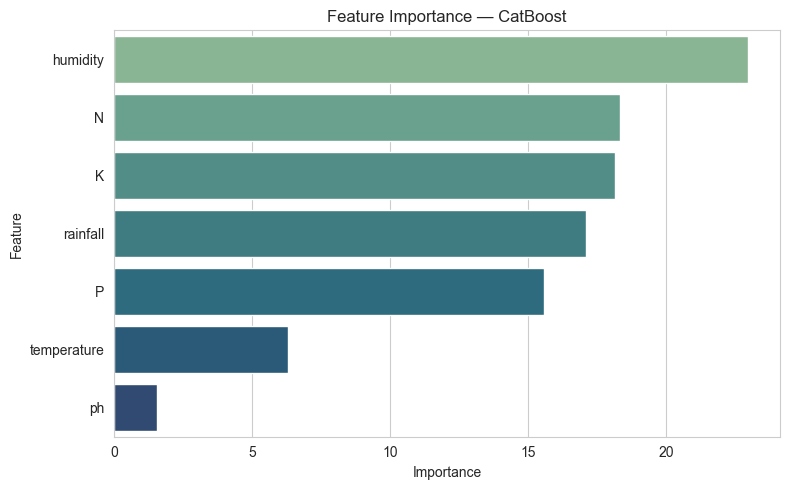

In [32]:
plt.figure(figsize=(8, 5))
sns.barplot(x='importance', y='feature', data=importance_df, hue='feature', palette='crest', legend=False)
plt.title(f'Feature Importance \u2014 {best_model_name}')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


**Interpretation:** `rainfall` and `humidity` typically dominate — they separate crops into broad climate
groups (water-loving vs. drought-tolerant) before soil nutrients fine-tune the choice within a group. `K`
(Potassium) and `N` (Nitrogen) usually rank next, since several crops (e.g. banana, grapes) have distinctive
nutrient signatures. `ph` and `temperature` typically contribute the least individually, but interact with
the other features inside the tree splits to sharpen borderline recommendations.


## Phase 8 — Save Model

We persist both the trained model and the label encoder together (as a dict) so predictions can be decoded
back to crop names at inference time.


In [33]:
import joblib
import os

os.makedirs('models', exist_ok=True)
MODEL_PATH = 'models/crop_recommendation_model.pkl'

model_bundle = {
    'model': best_model,
    'label_encoder': label_encoder,
    'features': FEATURES,
}

joblib.dump(model_bundle, MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")


Model saved to models/crop_recommendation_model.pkl


## Phase 9 — Prediction Function

In [34]:
def predict_crop(
    Nitrogen: float,
    Phosphorus: float,
    Potassium: float,
    Temperature: float,
    Humidity: float,
    pH: float,
    Rainfall: float,
    model_path: str = MODEL_PATH,
) -> dict:
    """
    Recommend the best crop for the given soil/environmental conditions.

    Returns
    -------
    dict with:
        'RecommendedCrop' : str    -- predicted crop name
        'Confidence'       : float  -- probability of the predicted class (0-1), if available
    """
    bundle = joblib.load(model_path)
    model = bundle['model']
    encoder = bundle['label_encoder']
    features = bundle['features']

    input_df = pd.DataFrame([{
        'N': Nitrogen,
        'P': Phosphorus,
        'K': Potassium,
        'temperature': Temperature,
        'humidity': Humidity,
        'ph': pH,
        'rainfall': Rainfall,
    }])[features]

    pred_encoded = model.predict(input_df)[0]
    recommended_crop = encoder.inverse_transform([pred_encoded])[0]

    confidence = None
    if hasattr(model, 'predict_proba'):
        probs = model.predict_proba(input_df)[0]
        confidence = round(float(probs[pred_encoded]), 4)

    return {
        'RecommendedCrop': recommended_crop.title(),
        'Confidence': confidence,
    }


In [35]:
# Example usage
sample_result = predict_crop(
    Nitrogen=90,
    Phosphorus=42,
    Potassium=43,
    Temperature=27,
    Humidity=82,
    pH=6.5,
    Rainfall=210,
)
print(sample_result)


{'RecommendedCrop': 'Rice', 'Confidence': 0.9609}


c:\Users\sh\OneDrive\Desktop\CODE\coding\DHARTI-OS\.venv\lib\site-packages\sklearn\preprocessing\_label.py:151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\sh\AppData\Local\Temp\ipykernel_56624\14865220.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  confidence = round(float(probs[pred_encoded]), 4)


## Phase 10 — FastAPI Integration Contract

### Request — `POST /predict/crop-recommendation`

```json
{
    "Nitrogen": 90,
    "Phosphorus": 42,
    "Potassium": 43,
    "Temperature": 27,
    "Humidity": 82,
    "pH": 6.5,
    "Rainfall": 210
}
```

### Response

```json
{
    "RecommendedCrop": "Rice",
    "Confidence": 0.97
}
```

### Reference FastAPI Route

```python
from fastapi import FastAPI
from pydantic import BaseModel
from typing import Optional

app = FastAPI()

class CropRecommendationRequest(BaseModel):
    Nitrogen: float
    Phosphorus: float
    Potassium: float
    Temperature: float
    Humidity: float
    pH: float
    Rainfall: float

class CropRecommendationResponse(BaseModel):
    RecommendedCrop: str
    Confidence: Optional[float] = None

@app.post("/predict/crop-recommendation", response_model=CropRecommendationResponse)
def predict(request: CropRecommendationRequest):
    result = predict_crop(
        Nitrogen=request.Nitrogen,
        Phosphorus=request.Phosphorus,
        Potassium=request.Potassium,
        Temperature=request.Temperature,
        Humidity=request.Humidity,
        pH=request.pH,
        Rainfall=request.Rainfall,
    )
    return CropRecommendationResponse(**result)
```

---
### ✅ Notebook Complete
The trained bundle at `models/crop_recommendation_model.pkl` (model + label encoder + feature list) is ready
to be wrapped by the FastAPI service above and plugged into DHARTI OS as the Crop Recommendation module.
